In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from itertools import product

import sys

from pathlib import Path
nb_dir = Path.cwd()
help_func_path = os.path.join(nb_dir,'helper_code')

sys.path.append(help_func_path) 

from plotting_functions import scatter_helper, plot_3d_scatters
from saving_functions import save_dataset,delete_dataset
from lmm_helper_funcs import latent_metric_model_gp

In [2]:
from scipy import stats
from sklearn.metrics.pairwise import rbf_kernel

In [3]:
DATA_ROOT = Path(os.environ["EPHEMERAL"]) / "pyspoc_synthetic_data"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

In [4]:
from sklearn.datasets import make_swiss_roll

In [5]:
Z,y = make_swiss_roll(n_samples=1000, noise=0.1, random_state=None, hole=True)

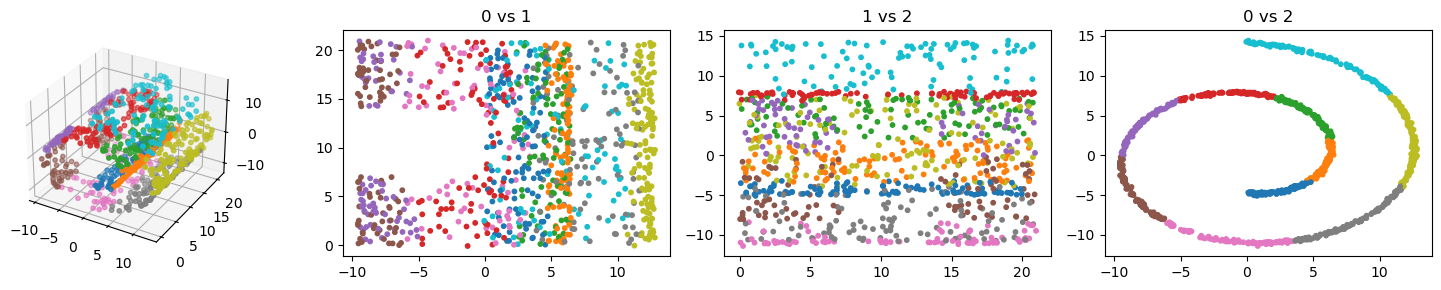

In [6]:
plot_3d_scatters(Z,'',y=y)

In [7]:
seed=0
random_states = {'latent' : seed+8291, 'gp' : seed+213, 'noise' : seed+4837}

X = latent_metric_model_gp(1000, 100, Z, 0.1, random_states, length_scale=1.0)

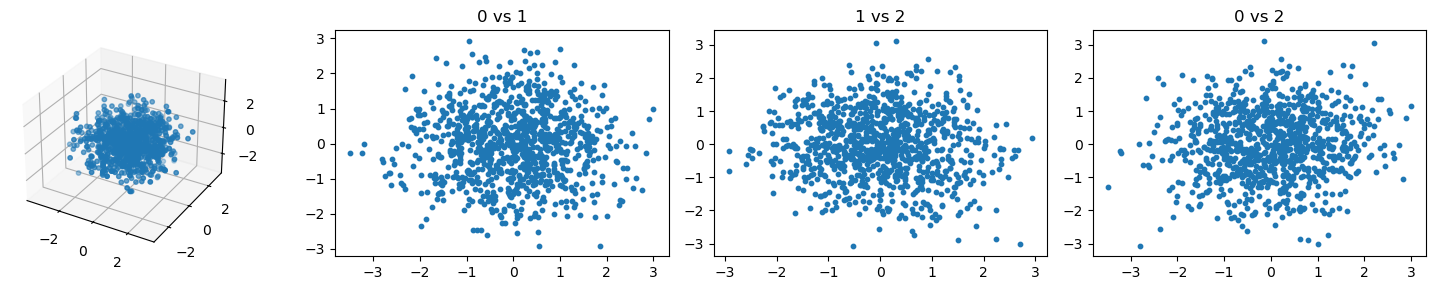

In [8]:
plot_3d_scatters(X,'')

In [15]:
# delete_dataset('gp_lmm_swissroll',DATA_ROOT)

In [ ]:
data_gen_name = 'gp_lmm_swissroll'
category_lst = ['density']

n_samples_lst = [1000,10000]
n_features_lst = [10,100,1000,10000]
random_seeds_lst = [80,26759]

lmm_noise_param = 0.1 ## for noise added to gp
lmm_len_scale_param = 1 ## for rbf-kernel

swissroll_noise_lst = [0.01,0.1]
sr_hole_lst = [True,False]

for n_samples, n_features in product(n_samples_lst, n_features_lst):
    
    print(n_samples, n_features)

    for sr_noise in swissroll_noise_lst:
        
        for sr_hole in sr_hole_lst:
        
            for sample_num,seed in enumerate(random_seeds_lst):
                
                random_states = {'latent' : seed+821, 'gp' : seed+323, 'noise' : seed+4237}
                
                Z,y = make_swiss_roll(n_samples=n_samples, noise=sr_noise, random_state=random_states['latent'], hole=sr_hole)                
                X = latent_metric_model_gp(n_samples, n_features, Z, lmm_noise_param, random_states, length_scale=lmm_len_scale_param)
                
                params_dict = {
                    'sr_noise' : sr_noise,
                    'sr_hole' : sr_hole,
                    'lmm_noise_param' : lmm_noise_param,
                    'lmm_len_scale_param' : lmm_len_scale_param,
                    'random_states_dict' : random_states
                }
                
                extra_arr = {
                    'sr_univariate_pos_sklearn' : y
                }
                                
                try:
                    save_dataset(X, 
                                generator=data_gen_name,
                                params=params_dict,
                                seed=seed,
                                category=category_lst,
                                extra_arrays=extra_arr, 
                                root=DATA_ROOT)
                    del(X)

                except:
                    print('error?')                    

1000 10
1000 100
1000 1000
1000 10000
10000 10
10000 100
10000 1000
10000 10000


(8, 8)


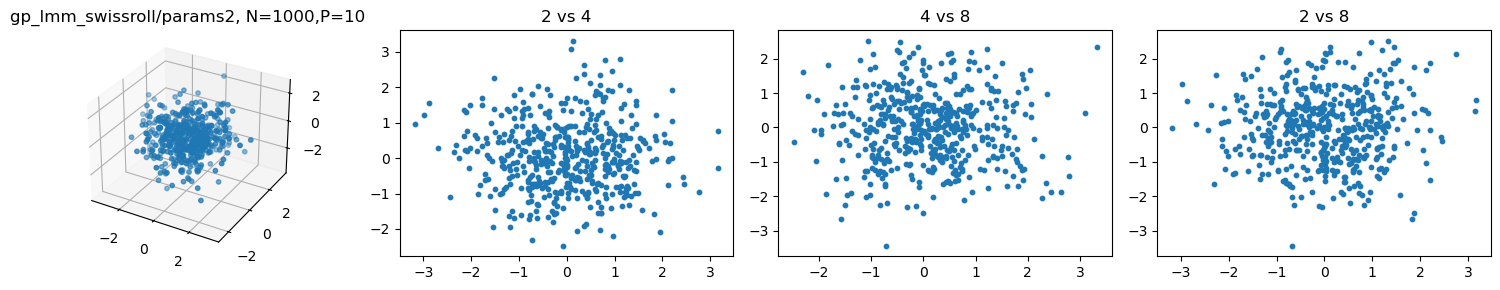

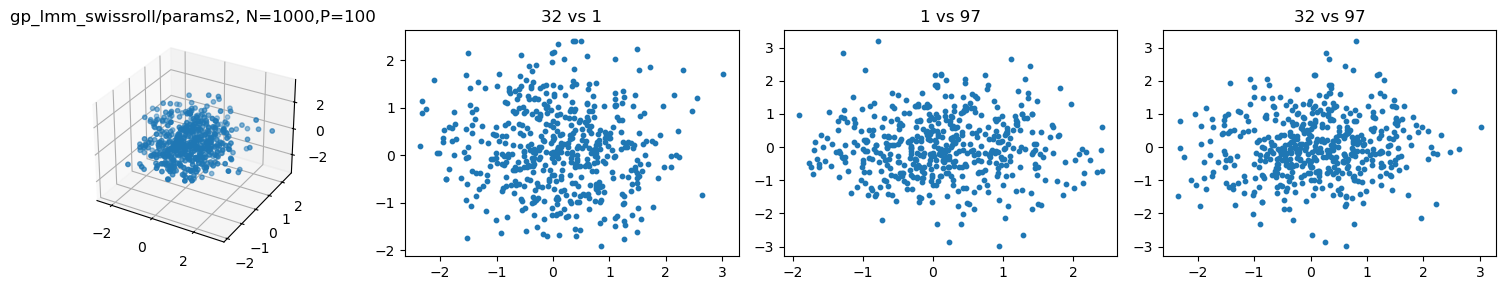

In [18]:
m = pd.read_csv(DATA_ROOT / "manifest.csv")

generator = data_gen_name
params_lst = [f'params{i}' for i in range(0,100) if i%8==2]
m = m[(m.generator == generator) & (m.params_id.isin(params_lst))]
print(m.shape)

max_pts = 500
for r in m.groupby(["generator", "params_id"]).head(2).itertuples():
    X = np.load(DATA_ROOT / f"{r.dataset_id}.npy")
    if len(X) > max_pts:
        rng = np.random.default_rng(0)       
        X = X[rng.choice(len(X), max_pts, replace=False)]
    plot_3d_scatters(X, f"{r.generator}/{r.params_id}, N={int(r.n_rows)},P={int(r.n_cols)}",custom_inx=np.random.choice(int(r.n_cols), 3, replace=False))

In [19]:
# m = pd.read_csv(DATA_ROOT / "manifest.csv")
# m['generator'].nunique()
# m.groupby(['n_rows','n_cols'])['dataset_id'].count()